In [59]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
calib_file_base = './proj_field'
# voltage to field relationship
base_volt_bpos_coeff, base_volt_bneg_coeff = np.loadtxt(calib_file_base + '_volt_center_calib.csv', delimiter=',')
base_volt_bpos_calib = np.poly1d(base_volt_bpos_coeff)
base_volt_bneg_calib = np.poly1d(base_volt_bneg_coeff)

# polar angle to radial distance calibration for positive and negative thetas
radial_polar_tpos_coeff, radial_polar_tneg_coeff = np.loadtxt(calib_file_base + '_radial_polar_calib.csv', delimiter=',')
radial_polar_tpos_calib = np.poly1d(radial_polar_tpos_coeff)
radial_polar_tneg_calib = np.poly1d(radial_polar_tneg_coeff)

# radial distance to voltage correction factor for positive and negative radial distances and positive and negative fields
volt_correction_rpos_bpos_coeff, volt_correction_rpos_bneg_coeff, volt_correction_rneg_bpos_coeff, volt_correction_rneg_bneg_coeff =  np.loadtxt(calib_file_base + '_volt_correction_calib.csv', delimiter=',')
volt_correction_rpos_bpos_calib = np.poly1d(volt_correction_rpos_bpos_coeff)
volt_correction_rpos_bneg_calib = np.poly1d(volt_correction_rpos_bneg_coeff)
volt_correction_rneg_bpos_calib = np.poly1d(volt_correction_rneg_bpos_coeff)
volt_correction_rneg_bneg_calib = np.poly1d(volt_correction_rneg_bneg_coeff)

In [51]:
B_req_vp = np.linspace(0,.2773,100)
B_req_vn = np.linspace(-0.2796,0,100)
V_calc_vp = base_volt_bpos_calib(B_req_vp)
V_calc_vn = base_volt_bneg_calib(B_req_vn)
V_calc_vp[-1], V_calc_vn[0] 

(9.998673994600239, -9.995064281266552)

In [54]:
B_cal_cent_vp = np.poly1d(np.polyfit(V_calc_vp, B_req_vp, 5))
B_cal_cent_vn = np.poly1d(np.polyfit(np.abs(V_calc_vn), np.abs(B_req_vn), 5))

Text(0, 0.5, 'Field (T)')

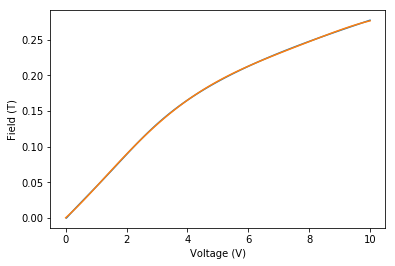

In [55]:
Vs = np.linspace(0,10,100)
Bs = B_cal_cent_vp(Vs)
plt.plot(V_calc_vp, B_req_vp)
plt.plot(Vs, Bs)
plt.xlabel("Voltage (V)")
plt.ylabel("Field (T)")

Text(0, 0.5, 'Field (T)')

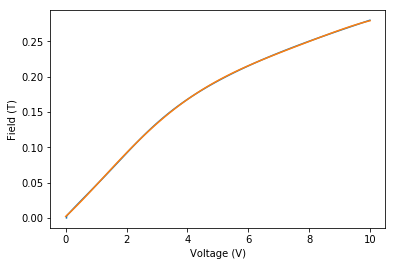

In [58]:
Vs = np.linspace(0,10,100)
Bs = B_cal_cent_vn(Vs)
plt.plot(np.abs(V_calc_vn), np.abs(B_req_vn))
# plt.plot(V_calc_vn, B_req_vn)
plt.plot(Vs, Bs)
plt.xlabel("Voltage (V)")
plt.ylabel("Field (T)")

In [67]:
theta_req_rn = np.linspace(0,90,100)
theta_req_rp = np.linspace(-90,0,100)
R_calc_rn = radial_polar_tpos_calib(theta_req_rn)
R_calc_rp = radial_polar_tneg_calib(theta_req_rp)

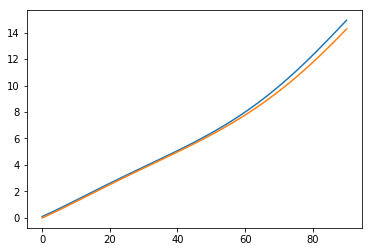

In [69]:
plt.plot(theta_req_rn, np.abs(R_calc_rn))
plt.plot(np.abs(theta_req_rp), R_calc_rp)

In [70]:
Vc_max_rp_vp = 10/volt_correction_rpos_bpos_calib(R_calc_rp)
Vc_max_rp_vn = 10/volt_correction_rpos_bneg_calib(R_calc_rp)
Vc_max_rn_vp = 10/volt_correction_rneg_bpos_calib(R_calc_rn)
Vc_max_rn_vn = 10/volt_correction_rneg_bneg_calib(R_calc_rn)

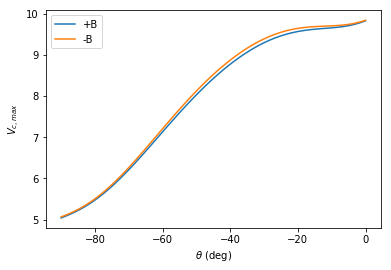

In [82]:
plt.plot(theta_req_rp, Vc_max_rp_vp, label='+B')
plt.plot(theta_req_rp, Vc_max_rp_vn, label='-B')
plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$V_{c,max}$')
plt.legend()

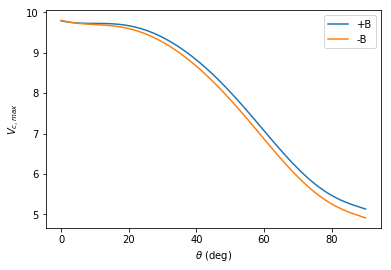

In [81]:
plt.plot(theta_req_rn, Vc_max_rn_vp, label='+B')
plt.plot(theta_req_rn, Vc_max_rn_vn, label='-B')
plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$V_{c,max}$')
plt.legend()

In [80]:
Bmag_max_rp_vp = B_cal_cent_vp(Vc_max_rp_vp)
Bmag_max_rn_vp = B_cal_cent_vp(Vc_max_rn_vp)
Bmag_max_rp_vn = B_cal_cent_vn(Vc_max_rp_vn)
Bmag_max_rn_vn = B_cal_cent_vn(Vc_max_rn_vn)

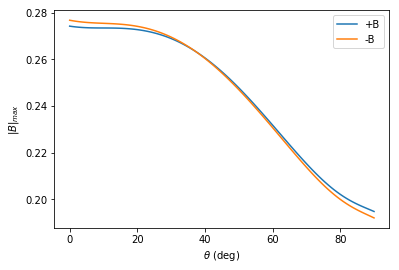

In [85]:
plt.plot(theta_req_rn, Bmag_max_rn_vp, label='+B')
plt.plot(theta_req_rn, Bmag_max_rn_vn, label='-B')
plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$|B|_{max}$')
plt.legend()

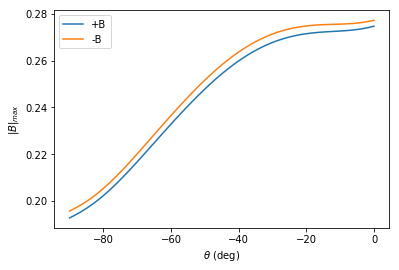

In [86]:
plt.plot(theta_req_rp, Bmag_max_rp_vp, label='+B')
plt.plot(theta_req_rp, Bmag_max_rp_vn, label='-B')
plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$|B|_{max}$')
plt.legend()

In [87]:
Bmag_max_rp_vp_IP = Bmag_max_rp_vp*np.cos(np.abs(theta_req_rp)*np.pi/180.)
Bmag_max_rp_vp_OOP = Bmag_max_rp_vp*np.sin(np.abs(theta_req_rp)*np.pi/180.)

Bmag_max_rp_vn_IP = Bmag_max_rp_vn*np.cos(np.abs(theta_req_rp)*np.pi/180.)
Bmag_max_rp_vn_OOP = Bmag_max_rp_vn*np.sin(np.abs(theta_req_rp)*np.pi/180.)

Bmag_max_rn_vp_IP = Bmag_max_rn_vp*np.cos(np.abs(theta_req_rn)*np.pi/180.)
Bmag_max_rn_vp_OOP = Bmag_max_rn_vp*np.sin(np.abs(theta_req_rn)*np.pi/180.)

Bmag_max_rn_vn_IP = Bmag_max_rn_vn*np.cos(np.abs(theta_req_rn)*np.pi/180.)
Bmag_max_rn_vn_OOP = Bmag_max_rn_vn*np.sin(np.abs(theta_req_rn)*np.pi/180.)


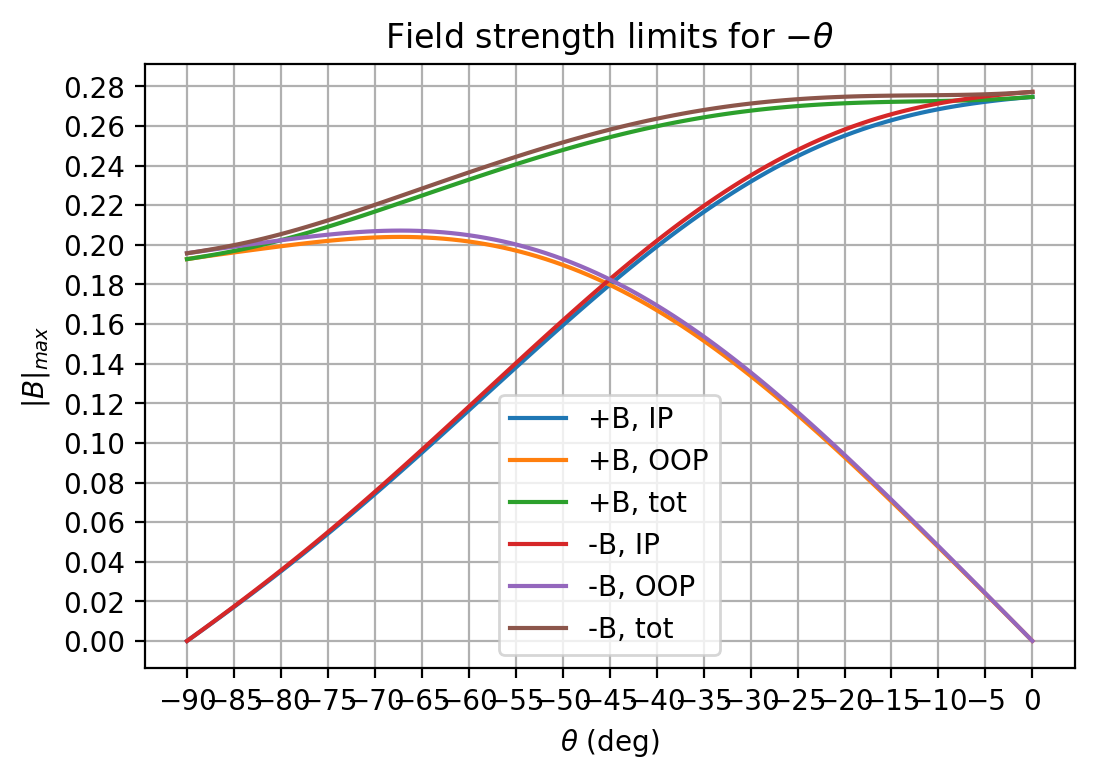

In [105]:
plt.figure(dpi=200)
plt.plot(theta_req_rp, Bmag_max_rp_vp_IP, label=('+B, IP'))
plt.plot(theta_req_rp, Bmag_max_rp_vp_OOP, label=('+B, OOP'))
plt.plot(theta_req_rp, Bmag_max_rp_vp, label=('+B, tot'))

plt.plot(theta_req_rp, Bmag_max_rp_vn_IP, label=('-B, IP'))
plt.plot(theta_req_rp, Bmag_max_rp_vn_OOP, label=('-B, OOP'))
plt.plot(theta_req_rp, Bmag_max_rp_vn, label=('-B, tot'))

plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$|B|_{max}$')
plt.title("Field strength limits for $-\\theta$")
plt.legend()
plt.xticks(np.arange(-90,5,5))
plt.yticks(np.arange(0.0,0.3,0.02))
plt.grid()

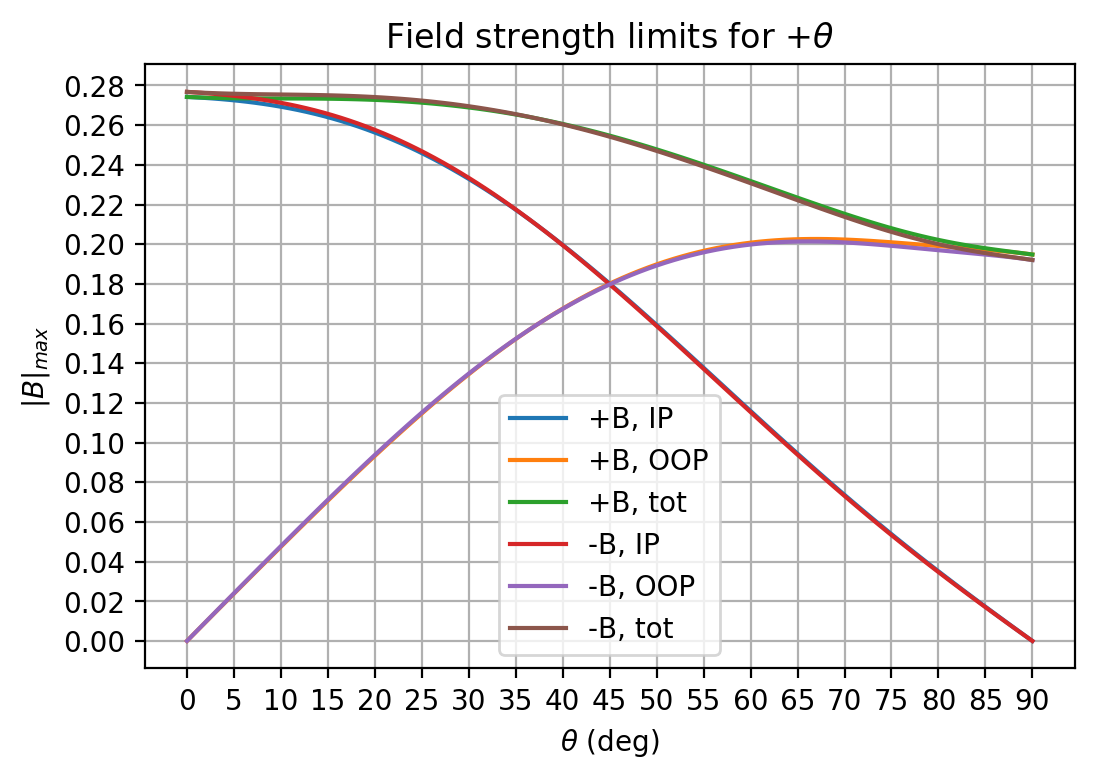

In [107]:
plt.figure(dpi=200)
plt.plot(theta_req_rn, Bmag_max_rn_vp_IP, label=('+B, IP'))
plt.plot(theta_req_rn, Bmag_max_rn_vp_OOP, label=('+B, OOP'))
plt.plot(theta_req_rn, Bmag_max_rn_vp, label=('+B, tot'))

plt.plot(theta_req_rn, Bmag_max_rn_vn_IP, label=('-B, IP'))
plt.plot(theta_req_rn, Bmag_max_rn_vn_OOP, label=('-B, OOP'))
plt.plot(theta_req_rn, Bmag_max_rn_vn, label=('-B, tot'))

plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$|B|_{max}$')
plt.title("Field strength limits for $+\\theta$")
plt.legend()
plt.xticks(np.arange(0,95,5))
plt.yticks(np.arange(0.0,0.3,0.02))
plt.grid()

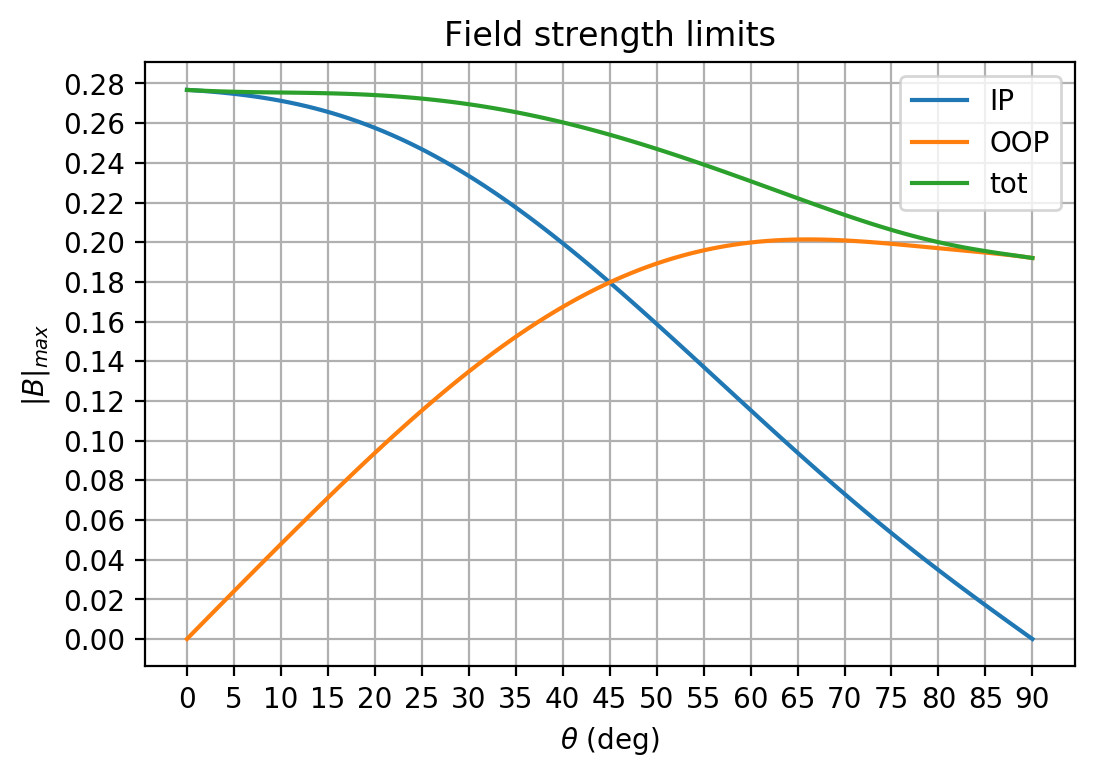

In [109]:
plt.figure(dpi=200)

plt.plot(theta_req_rn, Bmag_max_rn_vn_IP, label=('IP'))
plt.plot(theta_req_rn, Bmag_max_rn_vn_OOP, label=('OOP'))
plt.plot(theta_req_rn, Bmag_max_rn_vn, label=('tot'))

plt.xlabel('$\\theta$ (deg)')
plt.ylabel('$|B|_{max}$')
plt.title("Field strength limits")
plt.legend()
plt.xticks(np.arange(0,95,5))
plt.yticks(np.arange(0.0,0.3,0.02))
plt.grid()